In [35]:
# --- Imports ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from prophet import Prophet
import statsmodels.api as sm
import joblib


In [36]:
df = pd.read_csv("../data/Medical_appointment_data.csv")

In [37]:
# Convert appointment_date_continuous to datetime
df["appointment_date_continuous"] = pd.to_datetime(df["appointment_date_continuous"])


In [38]:
# Aggregate daily demand (overall)
daily_demand = df.groupby("appointment_date_continuous").size().reset_index(name="appointments")


In [39]:
# --- Chronological Train-Test Split ---
train_size = int(len(daily_demand) * 0.8)
train = daily_demand.iloc[:train_size]
test = daily_demand.iloc[train_size:]

print("Train period:", train["appointment_date_continuous"].min(), "to", train["appointment_date_continuous"].max())
print("Test period:", test["appointment_date_continuous"].min(), "to", test["appointment_date_continuous"].max())


Train period: 2020-01-01 00:00:00 to 2021-02-01 00:00:00
Test period: 2021-02-02 00:00:00 to 2021-05-12 00:00:00


In [40]:
# --- Baseline Model: SARIMA ---
sarima_model = sm.tsa.statespace.SARIMAX(train["appointments"],
                                         order=(2,1,2),
                                         seasonal_order=(1,1,1,7),
                                         enforce_stationarity=False,
                                         enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)

sarima_forecast = sarima_fit.predict(start=len(train), end=len(train)+len(test)-1, dynamic=False)


C:\Users\cxsha\PycharmProjects\medical_appt_noshowpredict_demandforecasting\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [42]:
# Evaluate SARIMA
# sarima_rmse = mean_squared_error(test["appointments"], sarima_forecast, squared=False)
# MSE
sarima_mse = mean_squared_error(test["appointments"], sarima_forecast)
# RMSE (manual square root)
sarima_rmse = np.sqrt(sarima_mse)
sarima_mae = mean_absolute_error(test["appointments"], sarima_forecast)
sarima_r2 = r2_score(test["appointments"], sarima_forecast)
sarima_mape = np.mean(np.abs((test["appointments"] - sarima_forecast) / test["appointments"])) * 100

print("\nSARIMA Results:")
print(f"RMSE: {sarima_rmse:.2f}, MAE: {sarima_mae:.2f}, R²: {sarima_r2:.3f}, MAPE: {sarima_mape:.2f}%")



SARIMA Results:
RMSE: 265.94, MAE: 185.74, R²: 0.124, MAPE: 2816.39%


In [43]:
# --- Advanced Model: Prophet ---
prophet_df = train.rename(columns={"appointment_date_continuous":"ds", "appointments":"y"})
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
prophet_model.fit(prophet_df)

future = test.rename(columns={"appointment_date_continuous":"ds"})
forecast = prophet_model.predict(future)


12:15:15 - cmdstanpy - INFO - Chain [1] start processing
12:15:15 - cmdstanpy - INFO - Chain [1] done processing


In [44]:
# Evaluate Prophet
# prophet_rmse = mean_squared_error(test["appointments"], forecast["yhat"], squared=False)

# MSE
prophet_mse = mean_squared_error(test["appointments"], forecast["yhat"])

# RMSE (manual square root)
prophet_rmse = np.sqrt(prophet_mse)
prophet_mae = mean_absolute_error(test["appointments"], forecast["yhat"])
prophet_r2 = r2_score(test["appointments"], forecast["yhat"])
prophet_mape = np.mean(np.abs((test["appointments"] - forecast["yhat"]) / test["appointments"])) * 100

print("\nProphet Results:")
print(f"RMSE: {prophet_rmse:.2f}, MAE: {prophet_mae:.2f}, R²: {prophet_r2:.3f}, MAPE: {prophet_mape:.2f}%")



Prophet Results:
RMSE: 449.40, MAE: 395.93, R²: -1.501, MAPE: nan%


In [45]:
# --- Compare Models ---
results = pd.DataFrame({
    "SARIMA": [sarima_rmse, sarima_mae, sarima_r2, sarima_mape],
    "Prophet": [prophet_rmse, prophet_mae, prophet_r2, prophet_mape]
}, index=["RMSE","MAE","R²","MAPE"])

print("\nModel Comparison:\n", results)



Model Comparison:
            SARIMA     Prophet
RMSE   265.942446  449.404481
MAE    185.738247  395.930645
R²       0.124213   -1.500909
MAPE  2816.389083         NaN


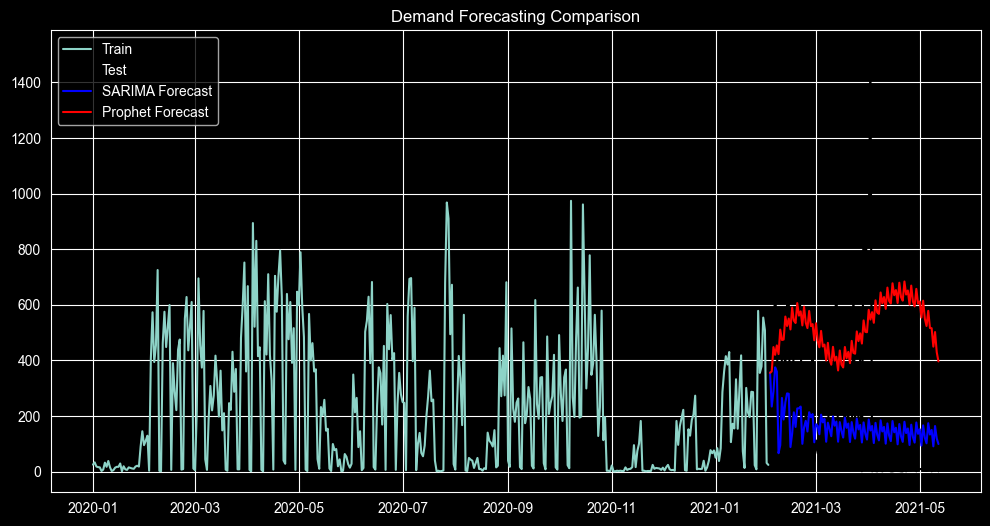

In [46]:
# --- Visualization ---
plt.figure(figsize=(12,6))
plt.plot(train["appointment_date_continuous"], train["appointments"], label="Train")
plt.plot(test["appointment_date_continuous"], test["appointments"], label="Test", color="black")
plt.plot(test["appointment_date_continuous"], sarima_forecast, label="SARIMA Forecast", color="blue")
plt.plot(test["appointment_date_continuous"], forecast["yhat"], label="Prophet Forecast", color="red")
plt.legend()
plt.title("Demand Forecasting Comparison")
plt.show()


In [48]:
# --- Save Best Model ---
if prophet_mape < sarima_mape:
    joblib.dump(prophet_model, "../models/demand_forecast_model.pkl")
    print("Best model (Prophet) saved to ../models/demand_forecast_model.pkl")
else:
    joblib.dump(sarima_fit, "../models/demand_forecast_model.pkl")
    print("Best model (SARIMA) saved to ../models/demand_forecast_model.pkl")

Best model (SARIMA) saved to ../models/demand_forecast_model.pkl
